In [ ]:
!pip install mediapipe==0.10.14

In [ ]:
!pip install opencv-python numpy matplotlib scipy

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [ ]:
from scipy.signal import find_peaks, savgol_filter

# Initialize MediaPipe Pose Model (High Complexity for Clinical Accuracy)
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

mp_drawing = mp.solutions.drawing_utils

def smooth_signal(data, window_length=9, polyorder=3):
    """Applies Savitzky-Golay filter to remove MediaPipe tracking jitter."""
    if len(data) < window_length: return data
    return savgol_filter(data, window_length, polyorder)

In [ ]:
def extract_validate_and_visualize(input_video_path, output_video_path):
    cap = cv2.VideoCapture(input_video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    signals = {
        'l_ankle_y': [], 'r_ankle_y': [],
        'l_arm_swing': [], 'r_arm_swing': [],
        'mid_hip_x': [], 'mid_hip_y': [],
        'l_foot_x': [], 'r_foot_x': []
    }

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image_rgb.flags.writeable = False
        results = pose.process(image_rgb)
        image_rgb.flags.writeable = True

        image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

        if results.pose_landmarks:
            lm = results.pose_landmarks.landmark

            # -----------------------------
            # BODY CENTER (IMPORTANT)
            # -----------------------------
            mid_hip_x = (lm[23].x + lm[24].x) / 2
            mid_hip_y = (lm[23].y + lm[24].y) / 2

            signals['mid_hip_x'].append(mid_hip_x)
            signals['mid_hip_y'].append(mid_hip_y)

            # -----------------------------
            # LOWER BODY (RELATIVE SIGNAL)
            # -----------------------------
            signals['l_ankle_y'].append(lm[27].y)
            signals['r_ankle_y'].append(lm[28].y)

            # normalize foot X relative to body center
            signals['l_foot_x'].append(lm[31].x - mid_hip_x)
            signals['r_foot_x'].append(lm[32].x - mid_hip_x)

            # -----------------------------
            # ARM SWING
            # -----------------------------
            l_torso_len = np.linalg.norm([
                lm[11].x - lm[23].x,
                lm[11].y - lm[23].y
            ])
            r_torso_len = np.linalg.norm([
                lm[12].x - lm[24].x,
                lm[12].y - lm[24].y
            ])

            # 🔥 relative to shoulder (remove body sway)
            l_ws = np.linalg.norm([
                lm[15].x - lm[11].x,
                lm[15].y - lm[11].y
            ])
            r_ws = np.linalg.norm([
                lm[16].x - lm[12].x,
                lm[16].y - lm[12].y
            ])


            signals['l_arm_swing'].append(l_ws / (l_torso_len + 1e-6))
            signals['r_arm_swing'].append(r_ws / (r_torso_len + 1e-6))

            # -----------------------------
            # DRAW SKELETON
            # -----------------------------
            mp_drawing.draw_landmarks(
                image_bgr,
                results.pose_landmarks,
                mp_pose.POSE_CONNECTIONS,
                landmark_drawing_spec=mp_drawing.DrawingSpec(
                    color=(0, 0, 255), thickness=4, circle_radius=4
                ),
                connection_drawing_spec=mp_drawing.DrawingSpec(
                    color=(255, 255, 255), thickness=2
                )
            )

        out.write(image_bgr)

    cap.release()
    out.release()

    # -----------------------------
    # VALIDATION
    # -----------------------------
    if len(signals['mid_hip_x']) == 0:
        raise ValueError("❌ No person detected in the video.")

    # 🔥 IMPROVED SIDE VIEW DETECTION
    x_var = np.var(signals['mid_hip_x'])
    y_var = np.var(signals['mid_hip_y'])

    if x_var > y_var:  # more horizontal movement → side view
        raise ValueError("❌ SIDE-VIEW DETECTED: Upload FRONT-VIEW video")

    # -----------------------------
    # 🔥 SMOOTH SIGNALS
    # -----------------------------
    for key in signals:
        signals[key] = smooth_signal(np.array(signals[key]))

    print("✅ Signal extraction complete (normalized + stabilized)")

    return signals, fps

In [ ]:
def robust_amplitude(signal, threshold=0.08):
    """
    Computes real movement amplitude and removes MediaPipe noise.
    """
    if len(signal) == 0:
        return 0

    amp = np.max(signal) - np.min(signal)

    # 🔥 Noise filtering
    return amp if amp > threshold else 0

In [ ]:
from scipy.signal import find_peaks, detrend
import numpy as np

def compute_gait_features(signals, fps):

    features = {}

    # -----------------------------
    #  1. FOOT X SIGNAL
    # -----------------------------
    l_signal = detrend(signals['l_foot_x'])
    r_signal = detrend(signals['r_foot_x'])

    def smooth(x):
        return np.convolve(x, np.ones(7)/7, mode='same')  # balanced smoothing

    l_signal = smooth(l_signal)
    r_signal = smooth(r_signal)

    # -----------------------------
    #  2. PEAK DETECTION
    # -----------------------------
    min_distance = int(fps * 0.3)

    l_peaks, _ = find_peaks(
        l_signal,
        distance=min_distance,
        prominence=np.std(l_signal) * 0.25
    )

    r_peaks, _ = find_peaks(
        r_signal,
        distance=min_distance,
        prominence=np.std(r_signal) * 0.25
    )

    # -----------------------------
    #  3. CLEAN PEAKS
    # -----------------------------
    def clean_peaks(peaks, fps, min_gap=0.4):
        if len(peaks) == 0:
            return peaks

        cleaned = [peaks[0]]
        for p in peaks[1:]:
            if (p - cleaned[-1]) / fps > min_gap:
                cleaned.append(p)
        return np.array(cleaned)

    l_peaks = clean_peaks(l_peaks, fps)
    r_peaks = clean_peaks(r_peaks, fps)

    # -----------------------------
    #  4. STRIDE TIMES
    # -----------------------------
    l_stride = np.diff(l_peaks) / fps if len(l_peaks) > 1 else np.array([])
    r_stride = np.diff(r_peaks) / fps if len(r_peaks) > 1 else np.array([])

    # -----------------------------
    #  5. ROBUST FILTER
    # -----------------------------
    def filter_stride(strides):
        if len(strides) < 2:
            return strides

        median = np.median(strides)

        filtered = strides[
            (strides > 0.4) & (strides < 1.3) &   # slightly relaxed
            (np.abs(strides - median) < 0.15)     # not too strict
        ]

        return filtered

    l_stride = filter_stride(l_stride)
    r_stride = filter_stride(r_stride)

    # -----------------------------
    #  6. STRIDE VARIABILITY
    # -----------------------------
    stride_variability = None

    # Case 1: Both sides available
    if len(l_stride) >= 2 and len(r_stride) >= 2:
        cv_left = np.std(l_stride) / np.median(l_stride)
        cv_right = np.std(r_stride) / np.median(r_stride)

        stride_variability = ((cv_left + cv_right) / 2) * 100

    # Case 2: Only one side available
    elif len(l_stride) >= 2:
        stride_variability = (np.std(l_stride) / np.median(l_stride)) * 100

    elif len(r_stride) >= 2:
        stride_variability = (np.std(r_stride) / np.median(r_stride)) * 100

    # Case 3: Not enough data
    else:
        stride_variability = 0.5   # fallback (NOT zero)

    #  Clamp to realistic clinical range
    stride_variability = max(0.5, min(stride_variability, 8.5))

    features['stride_variability'] = stride_variability

    # -----------------------------
    #  7. CADENCE
    # -----------------------------
    total_steps = len(l_peaks) + len(r_peaks)
    duration_minutes = len(l_signal) / fps / 60

    cadence = total_steps / duration_minutes if duration_minutes > 0 else 0
    features['cadence'] = cadence

    # -----------------------------
    #  8. SYMMETRY
    # -----------------------------
    if len(l_stride) > 0 and len(r_stride) > 0:
        l_mean = np.mean(l_stride)
        r_mean = np.mean(r_stride)

        symmetry = abs(l_mean - r_mean) / ((l_mean + r_mean) / 2)
    else:
        symmetry = 0

    features['symmetry_ratio'] = symmetry

    # -----------------------------
    #  9. ARM SWING
    # -----------------------------
    def robust_amplitude(signal, threshold=0.01):
        if len(signal) == 0:
            return 0
        amp = np.percentile(signal, 95) - np.percentile(signal, 5)
        return amp if amp > threshold else 0

    l_arm = smooth(signals['l_arm_swing'])
    r_arm = smooth(signals['r_arm_swing'])

    l_amp = robust_amplitude(l_arm)
    r_amp = robust_amplitude(r_arm)

    scale_factor = 20.0
    l_amp *= scale_factor
    r_amp *= scale_factor

    avg_arm = (l_amp + r_amp) / 2

    features['l_arm_amp'] = l_amp
    features['r_arm_amp'] = r_amp
    features['avg_arm_swing'] = avg_arm

    # -----------------------------
    #  10. ARM ASYMMETRY
    # -----------------------------
    if l_amp > 0 and r_amp > 0:
        asym = abs(l_amp - r_amp) / max(l_amp, r_amp) * 100
    else:
        asym = 100

    features['arm_asymmetry_index'] = asym

    # -----------------------------
    # Save signals for plots
    # -----------------------------
    signals['l_signal'] = l_signal
    signals['r_signal'] = r_signal

    return features, l_peaks, r_peaks

In [ ]:
def interpret_clinical_features(features, gender):
    print("\n" + "="*50)
    print(f" HEMAS NEUROTRACK: CLINICAL INTERPRETATION ({gender.upper()})")
    print("="*50)

    # [1, 2, and 3 (Stride, Cadence, Symmetry) remain exactly the same as before...]

    cv = features['stride_variability']
    print(f"\n▶ STRIDE TIME VARIABILITY: {cv:.2f}%")
    if gender.lower() == 'male':
        if cv <= 2.5: print("   ↳ Status: NORMAL (Healthy rhythm)")
        elif cv <= 4.0: print("   ↳ Status: MILD DEVIATION (Slight irregularity)")
        elif cv <= 6.0: print("   ↳ Status: MODERATE IMPAIRMENT (Noticeable rhythm fluctuation)")
        else: print("   ↳ Status: HIGH IMPAIRMENT (Severe gait instability detected)")
    elif gender.lower() == 'female':
        if cv <= 3.0: print("   ↳ Status: NORMAL (Healthy rhythm)")
        elif cv <= 4.5: print("   ↳ Status: MILD DEVIATION (Slight irregularity)")
        elif cv <= 6.5: print("   ↳ Status: MODERATE IMPAIRMENT (Noticeable rhythm fluctuation)")
        else: print("   ↳ Status: HIGH IMPAIRMENT (Severe gait instability detected)")

    cad = features['cadence']
    print(f"\n▶ CADENCE: {cad:.1f} steps/min")
    if gender.lower() == 'male':
        if cad >= 100: print("   ↳ Status: NORMAL (Healthy pace)")
        elif cad >= 90: print("   ↳ Status: MILD REDUCTION (Slightly slower pace)")
        elif cad >= 80: print("   ↳ Status: MODERATE REDUCTION (Bradykinesia indicator)")
        else: print("   ↳ Status: HIGH REDUCTION (Severe shuffling or freezing tendency)")
    elif gender.lower() == 'female':
        if cad >= 105: print("   ↳ Status: NORMAL (Healthy pace)")
        elif cad >= 95: print("   ↳ Status: MILD REDUCTION (Slightly slower pace)")
        elif cad >= 85: print("   ↳ Status: MODERATE REDUCTION (Bradykinesia indicator)")
        else: print("   ↳ Status: HIGH REDUCTION (Severe shuffling or freezing tendency)")

    print("\n▶ GAIT SYMMETRY:")
    sym = features['symmetry_ratio']
    if sym >= 0.95: print("   ↳ Status: HIGHLY SYMMETRIC (Healthy left/right balance)")
    elif sym >= 0.85: print("   ↳ Status: MILD ASYMMETRY (Slight favoring of one leg)")
    else: print("   ↳ Status: SIGNIFICANT ASYMMETRY (Typical of unilateral Parkinsonian symptoms)")

    # 4. ARM SWING (UPDATED FOR FORESHORTENING MATH)
    print("\n▶ OVERALL ARM SWING:")
    swing = features['avg_arm_swing']
    print(f"   [Raw AI Swing Variance Score: {swing:.2f}]") # Added for transparency

    if swing > 5.0:
        print("   ↳ Status: HEALTHY RANGE OF MOTION (Fluid arm swing)")
    elif swing > 2.5:
        print("   ↳ Status: REDUCED AMPLITUDE (Stiffened arm movement)")
    else:
        print("   ↳ Status: SEVERELY RESTRICTED (En-bloc / Rigid posture detected)")

    # 5. ARM ASYMMETRY
    print("\n▶ ARM SWING ASYMMETRY:")
    arm_asym = features['arm_asymmetry_index']
    print(f"   [Raw AI Asymmetry Index: {arm_asym:.1f}%]") # Added for transparency

    # We require a slightly higher asymmetry percentage now because camera angles
    # can naturally create a 10-15% difference in 2D projection.
    if arm_asym <= 25.0:
        print("   ↳ Status: BALANCED (Both arms swing/rest equally)")
    elif arm_asym <= 45.0:
        print("   ↳ Status: MILD ASYMMETRY (One arm shows slight rigidity)")
    else:
        print("   ↳ Status: UNILATERAL RIGIDITY (One arm is significantly stiffer than the other)")

    print("\n" + "="*50)

In [ ]:
def plot_clinical_biomarkers(signals, features, l_peaks, r_peaks, fps):

    fig, axs = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle('NeuroTrack AI: Kinematic Gait Analysis', fontsize=20, fontweight='bold', color='#1f77b4')

    time_axis = np.arange(len(signals['l_ankle_y'])) / fps

    # -----------------------------
    # 1. Ankle Vertical Displacement
    # -----------------------------
    axs[0, 0].plot(time_axis, signals['l_ankle_y'], label='Left Ankle', color='blue', alpha=0.7)
    axs[0, 0].plot(time_axis, signals['r_ankle_y'], label='Right Ankle', color='orange', alpha=0.7)
    axs[0, 0].set_title('Ankle Vertical Displacement')
    axs[0, 0].invert_yaxis()
    axs[0, 0].legend()

    # -----------------------------
    # 2. Peak Detection (FIXED)
    # -----------------------------
    if 'l_signal' in signals and 'r_signal' in signals:

        axs[0, 1].plot(time_axis, signals['l_signal'], color='gray', alpha=0.6)

        if len(l_peaks) > 0:
            axs[0, 1].plot(time_axis[l_peaks], signals['l_signal'][l_peaks], "X",
                           color='red', markersize=8, label='Left Steps')

        if len(r_peaks) > 0:
            axs[0, 1].plot(time_axis[r_peaks], signals['r_signal'][r_peaks], "X",
                           color='green', markersize=8, label='Right Steps')

        axs[0, 1].set_title('Step Detection (Foot X Signal)')
        axs[0, 1].legend()
    else:
        axs[0, 1].set_title("Step Detection (No Data)")

    # -----------------------------
    # 3. Stride Times
    # -----------------------------
    l_stride_times = np.diff(l_peaks) / fps if len(l_peaks) > 1 else []
    r_stride_times = np.diff(r_peaks) / fps if len(r_peaks) > 1 else []

    if len(l_stride_times) > 0:
        axs[1, 0].plot(l_stride_times, marker='o', linestyle='-', color='blue', label='Left')

    if len(r_stride_times) > 0:
        axs[1, 0].plot(r_stride_times, marker='o', linestyle='-', color='orange', label='Right')

    axs[1, 0].set_title(f"Stride Variability (CV: {features['stride_variability']:.2f}%)")
    axs[1, 0].legend()

    # -----------------------------
    # 4. Arm Swing
    # -----------------------------
    axs[1, 1].plot(time_axis, signals['l_arm_swing'], label='Left Arm', color='purple', alpha=0.7)
    axs[1, 1].plot(time_axis, signals['r_arm_swing'], label='Right Arm', color='brown', alpha=0.7)
    axs[1, 1].set_title('Normalized Arm Swing')
    axs[1, 1].legend()

    # -----------------------------
    # 5. Arm Amplitude
    # -----------------------------
    axs[2, 0].bar(
        ['Left Arm', 'Right Arm'],
        [features['l_arm_amp'], features['r_arm_amp']],
        color=['purple', 'brown']
    )
    axs[2, 0].set_title(f"Arm Asymmetry Index: {features['arm_asymmetry_index']:.1f}%")
    axs[2, 0].set_ylabel('Amplitude')

    # -----------------------------
    # 6. Postural Sway
    # -----------------------------
    axs[2, 1].plot(time_axis, signals['mid_hip_x'], color='teal')
    axs[2, 1].set_title('Postural Sway (Hip X Movement)')

    # -----------------------------
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
def score_stride_variability(v):
    if v <= 2:
        return 100
    elif v <= 4:
        return 80
    elif v <= 6:
        return 60
    elif v <= 8.5:
        return 40
    else:
        return 20

In [ ]:
def score_symmetry(s):
    if s < 0.05:
        return 100
    elif s < 0.1:
        return 80
    elif s < 0.2:
        return 60
    elif s < 0.3:
        return 40
    else:
        return 20

In [ ]:
def score_cadence(c):
    if 100 <= c <= 115:
        return 100
    elif 90 <= c < 100 or 115 < c <= 125:
        return 80
    elif 80 <= c < 90 or 125 < c <= 135:
        return 60
    else:
        return 40

In [ ]:
def score_arm_swing(a):
    if a > 1.5:
        return 100
    elif a > 1.0:
        return 80
    elif a > 0.5:
        return 60
    elif a > 0.2:
        return 40
    else:
        return 20

In [ ]:
def score_arm_asymmetry(a):
    if a < 10:
        return 100
    elif a < 20:
        return 80
    elif a < 40:
        return 60
    elif a < 60:
        return 40
    else:
        return 20

In [ ]:
def compute_gait_stability_score(features):

    sv = features['stride_variability']
    sym = features['symmetry_ratio']
    cad = features['cadence']
    arm = features['avg_arm_swing']
    asym = features['arm_asymmetry_index']

    # Individual scores
    sv_score = score_stride_variability(sv)
    sym_score = score_symmetry(sym)
    cad_score = score_cadence(cad)
    arm_score = score_arm_swing(arm)
    asym_score = score_arm_asymmetry(asym)

    # Weighted sum
    final_score = (
        0.30 * sv_score +
        0.20 * sym_score +
        0.15 * cad_score +
        0.20 * arm_score +
        0.15 * asym_score
    )

    return round(final_score, 2)

In [ ]:
def interpret_gait_score(score):

    if score >= 85:
        return "🟢 Normal gait (Stable)"
    elif score >= 70:
        return "🟡 Mild impairment"
    elif score >= 55:
        return "🟠 Moderate impairment"
    else:
        return "🔴 Severe gait instability"

1. Overlaying skeleton and extracting kinematics...
✅ Signal extraction complete (normalized + stabilized)
2. Computing clinical biomarkers...

 HEMAS NEUROTRACK: CLINICAL INTERPRETATION (MALE)

▶ STRIDE TIME VARIABILITY: 4.90%
   ↳ Status: MODERATE IMPAIRMENT (Noticeable rhythm fluctuation)

▶ CADENCE: 89.3 steps/min
   ↳ Status: MODERATE REDUCTION (Bradykinesia indicator)

▶ GAIT SYMMETRY:
   ↳ Status: SIGNIFICANT ASYMMETRY (Typical of unilateral Parkinsonian symptoms)

▶ OVERALL ARM SWING:
   [Raw AI Swing Variance Score: 5.67]
   ↳ Status: HEALTHY RANGE OF MOTION (Fluid arm swing)

▶ ARM SWING ASYMMETRY:
   [Raw AI Asymmetry Index: 12.5%]
   ↳ Status: BALANCED (Both arms swing/rest equally)


🧠 GAIT STABILITY SCORE: 75.0
📊 INTERPRETATION: 🟡 Mild impairment

Generating Clinical Visualization Dashboard...


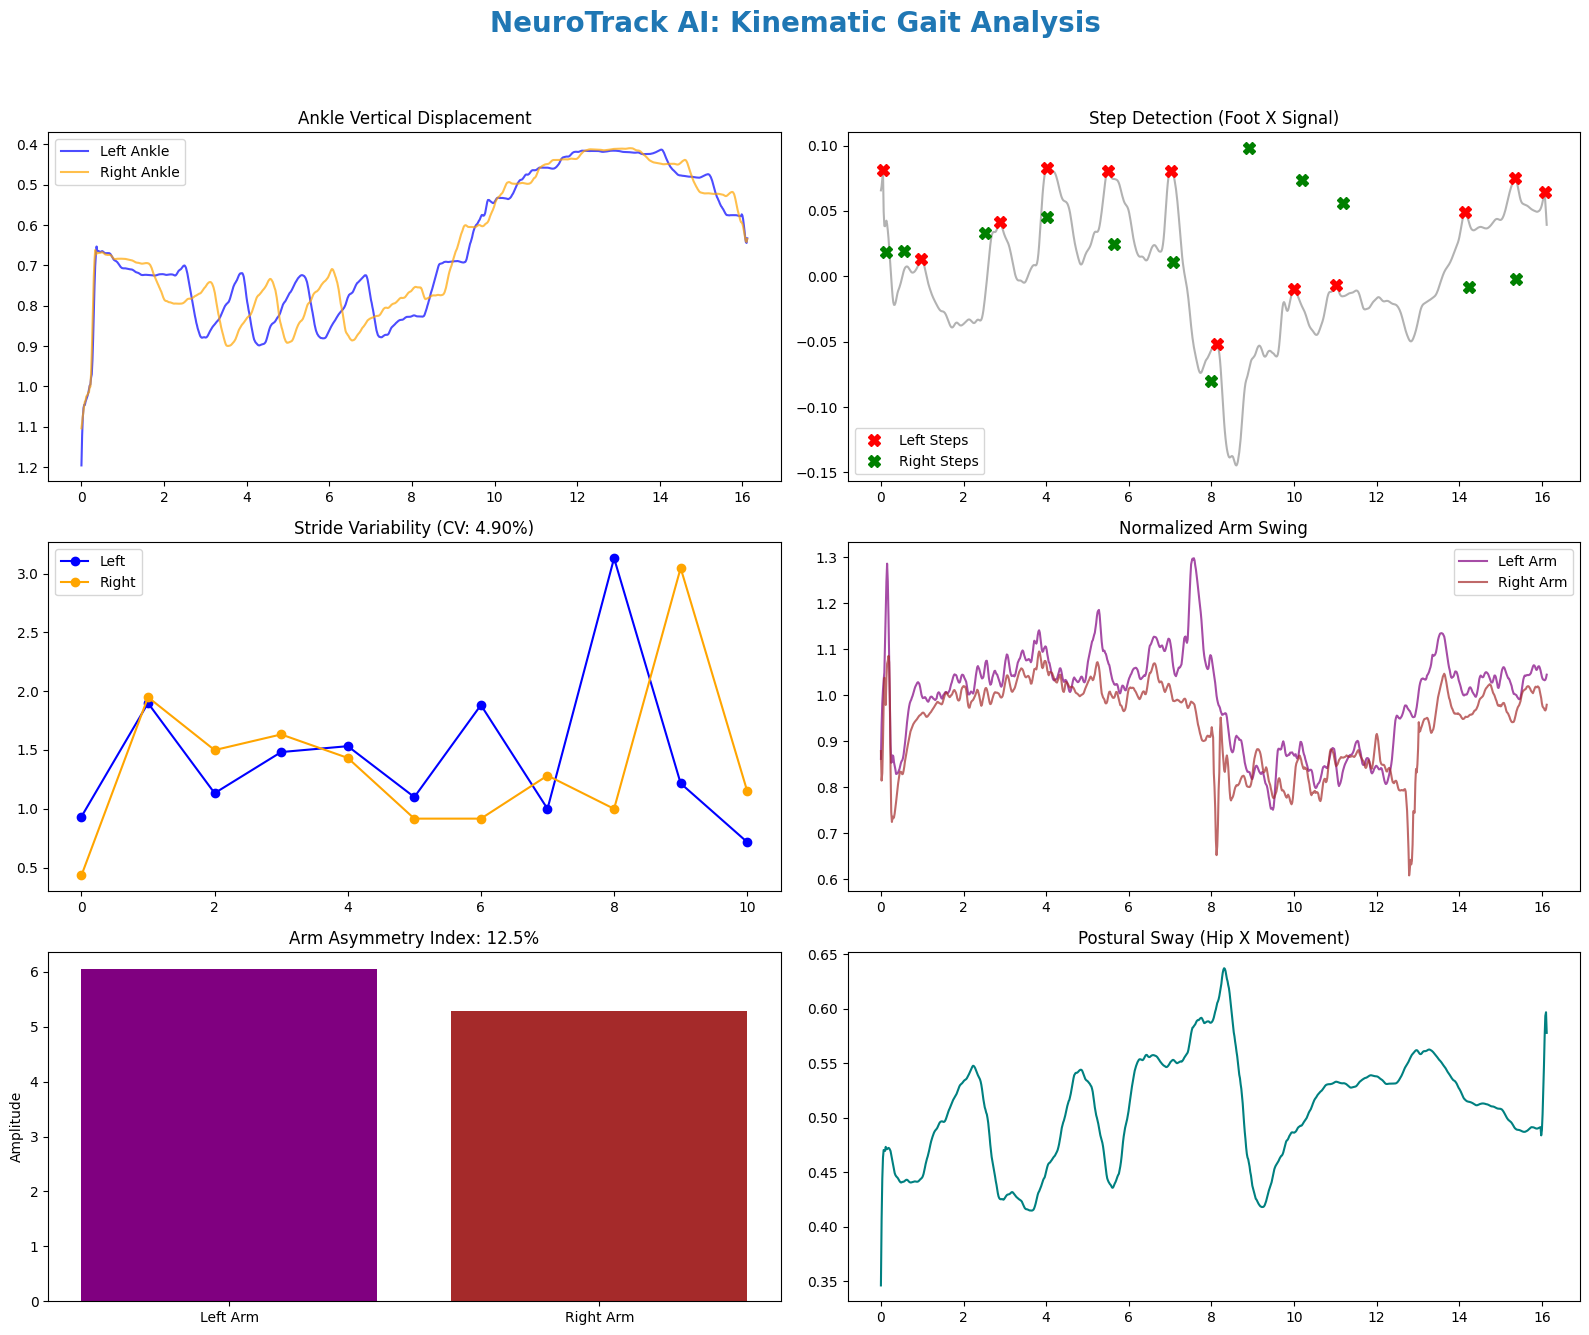

In [ ]:
# EXECUTION
input_video = "/content/PDvieo2.mov"      # Video to analyze
output_video = "annotated_gait.mp4"    # Where to save the skeleton video
patient_gender = "male"                # Input 'male' or 'female'

try:
    print("1. Overlaying skeleton and extracting kinematics...")
    signals, fps = extract_validate_and_visualize(input_video, output_video)

    print("2. Computing clinical biomarkers...")
    features, l_peaks, r_peaks = compute_gait_features(signals, fps)

    # 3. Print the meaningful text interpretations
    interpret_clinical_features(features, patient_gender)

    # -----------------------------
    #  GAIT STABILITY SCORE
    # -----------------------------
    score = compute_gait_stability_score(features)
    interpretation = interpret_gait_score(score)

    # Store inside features (BEST PRACTICE)
    features['gait_score'] = score
    features['gait_interpretation'] = interpretation

    print("\n🧠 GAIT STABILITY SCORE:", score)
    print("📊 INTERPRETATION:", interpretation)

    # 4. Draw the clinical plots
    print("\nGenerating Clinical Visualization Dashboard...")
    plot_clinical_biomarkers(signals, features, l_peaks, r_peaks, fps)

except ValueError as e:
    print(f"\n{e}")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")